# Step 6: Baseline Model Training


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

sys.path.insert(0, os.path.abspath(os.path.join('..', 'Src')))

from data.split_time_series import train_test_split_time, time_series_split
from models.logistic_regression import train_logistic, predict_logistic
from models.decision_tree import train_decision_tree, predict_decision_tree
from models.random_forest import train_random_forest, predict_random_forest

PROCESSED_DIR = os.path.join('..', 'Data', 'Processed')
FIGURES_DIR = os.path.join('..', 'Reports', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print("Setup complete.")

Setup complete.


---
## 1. Load Modeling Dataset

In [2]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'modeling_dataset.csv'), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Define features and target
EXCLUDE = ['date', 'ticker', 'log_return', 'fwd_sharpe', 'target']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print(f"Dataset: {len(df):,} rows")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target balance: {df['target'].mean()*100:.1f}% positive")

Dataset: 7,820 rows
Features (10): ['momentum_5d', 'excess_return', 'price_to_ma_21d', 'price_to_ma_50d', 'momentum_21d', 'roc', 'price_to_ma_200d', 'momentum_63d', 'momentum_126d', 'beta']
Target balance: 48.7% positive


---
## 2. Time-Series Train/Test Split

**80% train (earlier dates) / 20% test (later dates)**


In [3]:
train_df, test_df = train_test_split_time(df, train_ratio=0.8)

X_train = train_df[FEATURE_COLS].values
y_train = train_df['target'].values
X_test = test_df[FEATURE_COLS].values
y_test = test_df['target'].values

print(f"Train: {len(train_df):,} rows ({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"Test:  {len(test_df):,} rows ({test_df['date'].min().date()} to {test_df['date'].max().date()})")
print(f"\nTrain target balance: {y_train.mean()*100:.1f}%")
print(f"Test target balance:  {y_test.mean()*100:.1f}%")

Train: 6,256 rows (2019-10-17 to 2024-10-08)
Test:  1,564 rows (2024-10-08 to 2026-01-07)

Train target balance: 49.3%
Test target balance:  46.4%


---
## 3. Train Baseline Models

In [4]:
# Store results
results = {}

# 1. Logistic Regression
print("Training Logistic Regression...")
lr_model, lr_scaler = train_logistic(X_train, y_train)
lr_probs = predict_logistic(lr_model, lr_scaler, X_test)
results['Logistic Regression'] = {
    'model': lr_model,
    'scaler': lr_scaler,
    'probs': lr_probs,
    'auc': roc_auc_score(y_test, lr_probs),
    'acc': accuracy_score(y_test, (lr_probs > 0.5).astype(int))
}
print(f"  AUC: {results['Logistic Regression']['auc']:.4f}")

# 2. Decision Tree
print("\nTraining Decision Tree...")
dt_model = train_decision_tree(X_train, y_train, max_depth=5)
dt_probs = predict_decision_tree(dt_model, X_test)
results['Decision Tree'] = {
    'model': dt_model,
    'probs': dt_probs,
    'auc': roc_auc_score(y_test, dt_probs),
    'acc': accuracy_score(y_test, (dt_probs > 0.5).astype(int))
}
print(f"  AUC: {results['Decision Tree']['auc']:.4f}")

# 3. Random Forest
print("\nTraining Random Forest...")
rf_model = train_random_forest(X_train, y_train, n_estimators=100, max_depth=5)
rf_probs = predict_random_forest(rf_model, X_test)
results['Random Forest'] = {
    'model': rf_model,
    'probs': rf_probs,
    'auc': roc_auc_score(y_test, rf_probs),
    'acc': accuracy_score(y_test, (rf_probs > 0.5).astype(int))
}
print(f"  AUC: {results['Random Forest']['auc']:.4f}")

Training Logistic Regression...
  AUC: 0.5408

Training Decision Tree...
  AUC: 0.5215

Training Random Forest...
  AUC: 0.5584


---
## 4. Compare Model Performance

In [5]:
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"{'Model':<25} {'AUC':>10} {'Accuracy':>10}")
print("-"*50)
for name, res in results.items():
    print(f"{name:<25} {res['auc']:>10.4f} {res['acc']:>10.4f}")
print("="*50)

# Check for suspiciously good performance
best_auc = max(r['auc'] for r in results.values())
if best_auc > 0.65:
    print("\nWARNING: AUC > 0.65 is suspicious for financial prediction.")
    print("         Investigate for potential leakage!")
elif best_auc < 0.52:
    print("\nNOTE: AUC close to 0.5 suggests weak signal.")
    print("      This is NORMAL for financial data.")
else:
    print("\nPerformance looks reasonable for financial prediction.")


MODEL COMPARISON
Model                            AUC   Accuracy
--------------------------------------------------
Logistic Regression           0.5408     0.5217
Decision Tree                 0.5215     0.4987
Random Forest                 0.5584     0.5281

Performance looks reasonable for financial prediction.


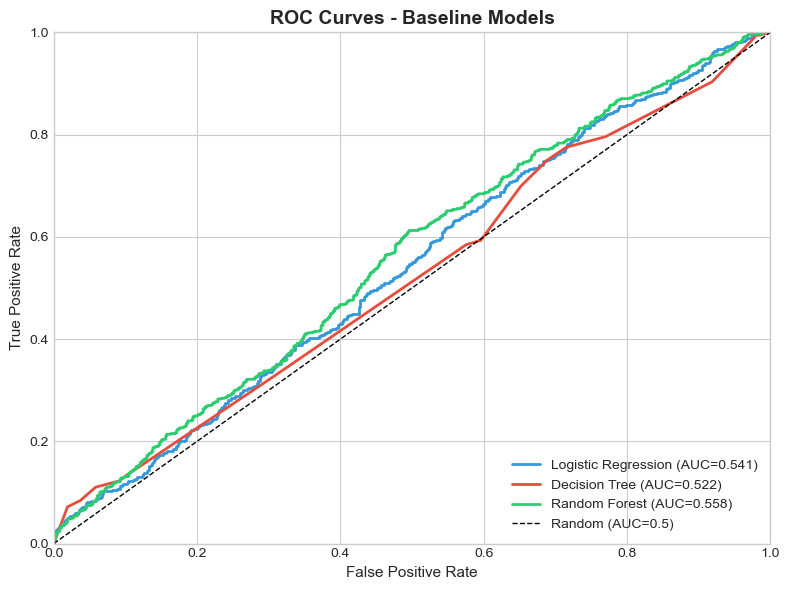

Saved: baseline_roc_curves.png


In [6]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves - Baseline Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'baseline_roc_curves.png'), dpi=150)
plt.show()
print("Saved: baseline_roc_curves.png")

---
## 5. Feature Importance (Random Forest)

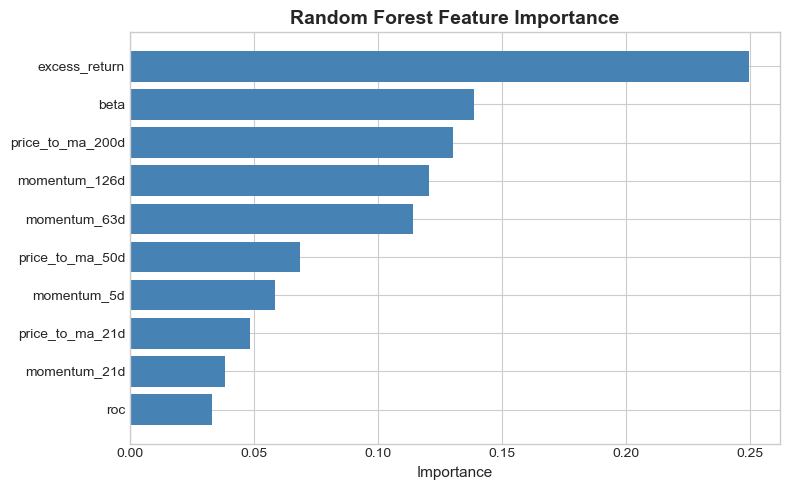


Top features:
  excess_return: 0.2496
  beta: 0.1386
  price_to_ma_200d: 0.1302
  momentum_126d: 0.1204
  momentum_63d: 0.1143


In [7]:
# Feature importance from Random Forest
importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_importance.png'), dpi=150)
plt.show()

print("\nTop features:")
for _, row in importance.tail(5).iloc[::-1].iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

---
## 6. Cross-Validation (Time-Series)

In [8]:
# Walk-forward cross-validation
print("Running walk-forward cross-validation...\n")

cv_results = {'Logistic Regression': [], 'Decision Tree': [], 'Random Forest': []}

for fold, (train_idx, test_idx) in enumerate(time_series_split(df, n_splits=5, test_size=0.15)):
    X_tr = df.iloc[train_idx][FEATURE_COLS].values
    y_tr = df.iloc[train_idx]['target'].values
    X_te = df.iloc[test_idx][FEATURE_COLS].values
    y_te = df.iloc[test_idx]['target'].values
    
    # Logistic Regression
    m, s = train_logistic(X_tr, y_tr)
    p = predict_logistic(m, s, X_te)
    cv_results['Logistic Regression'].append(roc_auc_score(y_te, p))
    
    # Decision Tree
    m = train_decision_tree(X_tr, y_tr)
    p = predict_decision_tree(m, X_te)
    cv_results['Decision Tree'].append(roc_auc_score(y_te, p))
    
    # Random Forest
    m = train_random_forest(X_tr, y_tr)
    p = predict_random_forest(m, X_te)
    cv_results['Random Forest'].append(roc_auc_score(y_te, p))
    
    print(f"Fold {fold+1}: LR={cv_results['Logistic Regression'][-1]:.3f}, "
          f"DT={cv_results['Decision Tree'][-1]:.3f}, "
          f"RF={cv_results['Random Forest'][-1]:.3f}")

print("\n" + "="*50)
print("CROSS-VALIDATION SUMMARY")
print("="*50)
for name, aucs in cv_results.items():
    print(f"{name:<25} Mean: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}")

Running walk-forward cross-validation...

Fold 1: LR=0.529, DT=0.502, RF=0.554
Fold 2: LR=0.582, DT=0.649, RF=0.608
Fold 3: LR=0.428, DT=0.440, RF=0.412
Fold 4: LR=0.542, DT=0.508, RF=0.558
Fold 5: LR=0.539, DT=0.531, RF=0.549

CROSS-VALIDATION SUMMARY
Logistic Regression       Mean: 0.5241 +/- 0.0513
Decision Tree             Mean: 0.5260 +/- 0.0685
Random Forest             Mean: 0.5362 +/- 0.0658


---
## 7. Save Predictions

In [9]:
# Save test predictions
predictions = test_df[['date', 'ticker', 'target']].copy()
predictions['lr_prob'] = lr_probs
predictions['dt_prob'] = dt_probs
predictions['rf_prob'] = rf_probs

pred_path = os.path.join(PROCESSED_DIR, 'baseline_predictions.csv')
predictions.to_csv(pred_path, index=False)
print(f"Saved predictions: {pred_path}")
print(f"Shape: {predictions.shape}")

Saved predictions: ..\Data\Processed\baseline_predictions.csv
Shape: (1564, 6)
